In [1]:
# Analysis of surface area calculation


In [88]:
import os
from pathlib import Path
cache_path       = Path('/data/crcns2021/hcpannot-cache')
image_cache_path = cache_path / 'annot-images'
v123_cache_path  = cache_path / 'annot-v123'
csulc_cache_path = cache_path / 'annot-csulc'
# The save path of the data branch:
data_path = Path('/data/crcns2021/results/data_branch/save')
# The processing path and subpaths:
proc_path    = Path('/data/crcns2021/results/proc')
traces_path  = proc_path / 'traces'
paths_path   = proc_path / 'paths'
means_path   = proc_path / 'means'
labels_path  = proc_path / 'labels'
reports_path = proc_path / 'reports'
fig_dir      = proc_path / 'figures'

# The file of visual surface areas for the ventral data.
ventral_sarea_path = proc_path / 'ventral_sareas.tsv'

# The hcpannot library path; if hcpannot is not on the path for
# this notebook, the notebook will try to figure out where it is
# and will use this directory as a backup.
hcpannot_lib_path = Path('~/code/hcp-annot-vc_analysis')

# If you aren't using /data
os.environ['HCPANNOT_LOAD_PATH'] = os.fspath(cache_path)

In [89]:
# import necessary packages
import sys
sys.path.append('../src/')
import hcpannot
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as st 
import neuropythy as ny
import matplotlib as mpl
import itertools
import warnings
import pingouin as pg
import random
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from itertools import product
sys.path.append('../src/hcpannot/')
from visualization import plot_annot_properties as vis
from visualization import twin_analysis as tw
from hcpannot.config import subject_list, ventral_raters, dorsal_raters, region_areas
from hcpannot.io import load_allreports
from hcpannot.proc import proc, allproc, proc_meanrater
from hcpannot.io import plot_contours


# Note the cache path we want to use outside the docker container;
# normally this gets set by the Docker startup, so here outside
# the docker container we set it manually.
hcpannot.interface.default_load_path = str(cache_path)

# The subject IDs we are processing over, as a numpy array.
sids = np.array(subject_list)
hemis = ['lh', 'rh']

warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [90]:
# Additional matplotlib preferences:
font_data = {'family':'sans-serif',
             'sans-serif':['HelveticaNeue'],
             'size': 12,
             'weight': 'light'}
mpl.rc('font',**font_data)
# we want relatively high-res images, especially when saving to disk.
mpl.rcParams['figure.dpi'] = 72*3
mpl.rcParams['savefig.dpi'] = 72*4
mpl.rcParams['axes.unicode_minus'] = False

rc = {'text.color': 'black',
      'axes.labelcolor': 'black',
      'axes.labelweight': 'light',
      'axes.linewidth':     0.8,
      'xtick.major.width':    0.8,
      'ytick.major.width':    0.8,
      'xtick.color': 'black',
      'ytick.color': 'black',
      'xtick.labelcolor': 'black',
      'ytick.labelcolor': 'black',
      'font.family': 'helveticaneue',
      'font.weight': 'light',
      'font.size' : 12,
      'figure.dpi': 72*3,
      'savefig.dpi': 72*4,
      }
mpl.rcParams.update(rc)

In [91]:
# What traces do we want to plot and what style? By putting thicker lines (lw)
# and larger markers (ms) on the bottom (lower zorder) we can see multiple
# contours that overlap.
plot_opts = dict(
    hV4_outer=dict(c='r', lw=0.5, ms=1, zorder=2),
    VO_outer=dict(c='r', lw=0.5, ms=1, zorder=2),
    hV4_VO1=dict(c='r', lw=0.5, ms=1, zorder=3),
    VO1_VO2=dict(c='r', lw=0.5, ms=1, zorder=3))

In [92]:
hemi = 'lh'
sid = '100610'
region = 'ventral'

dat1 = proc(region,
              rater='R4',
              hemisphere=hemi,
              sid=sid,
              load_path=data_path,
              save_path=proc_path)
# Extract the flatmap and the traces.
fmap = dat1['flatmap']

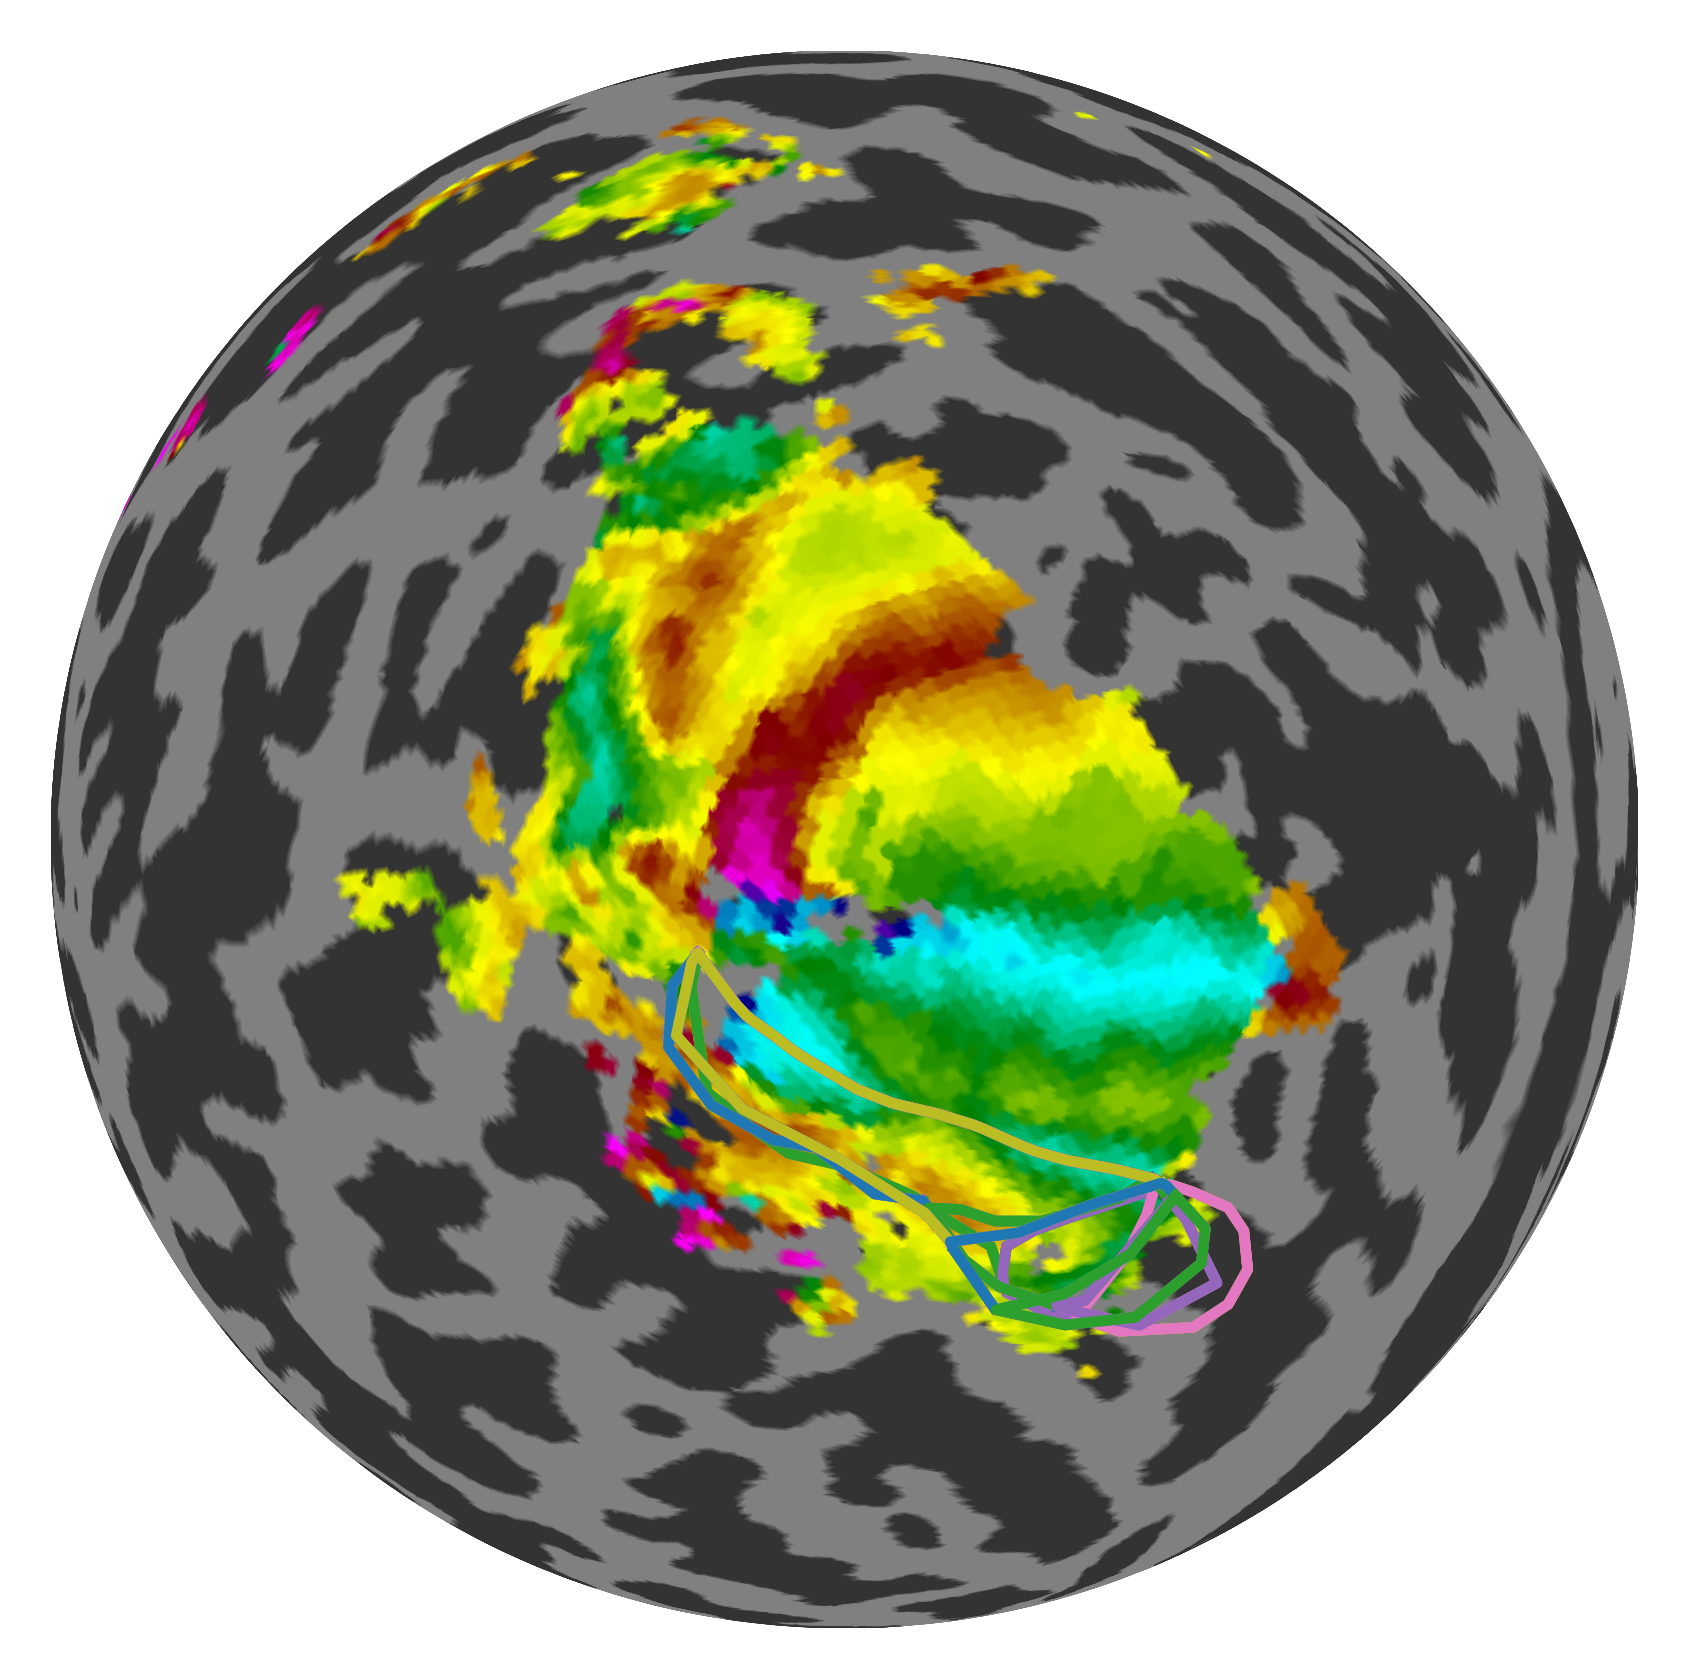

In [99]:
plt.close('all')

# Extract the flatmap and the traces.
fmap = dat1['flatmap']
plot_color = 'prf_polar_angle'
plot_mask = ('prf_variance_explained', 0.1, 1)

# Make a figure with one set of axes and plot the flatmap on it.
(fig,ax) = plt.subplots(1,1, figsize=(4,4), dpi=512)
ny.cortex_plot(fmap, color=plot_color, mask=plot_mask, axes=ax)

##
researcher_list = ['R1','R2','R4']
color_list = ['k', 'c','r']
# Plot each of the traces in the plot_opts:
for researcher, color in zip(researcher_list, color_list):
    dat = proc(region,
              rater=researcher,
              hemisphere=hemi,
              sid=sid,
              load_path=data_path,
              save_path=proc_path)
    for key, value in dat['traces'].items():
        (x,y) = value.curve.coordinates
        ax.plot(x, y, '-', color)

# # Plot the V1-V3 contours also:
# sdat = hcpannot.interface.subject_data[(sid, hemi)]
# for (x,y) in sdat['v123'].values():
#     ax.plot(x, y, 'o', c='0.5', ms=0.15)
ax.axis('off')
ax.set(xlim=(-100,100), ylim=(-100,100)) 
plt.show()

In [ ]:
# polar angle and eccentricity
# find a subject that has a big difference in the foveal part drawings 